In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn.conv import GATConv, GCNConv, SplineConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
import matplotlib.pyplot as plt
from Model.MENDR.MENDR import MENDR_model
from Model.MENDR.MENDREncoder import MENDRPatchEncoder
from Model.MENDR.mAtt.optimizer import MixOptimizer
from Model.MENDR.mAtt.spd import SPDTangentSpace
import random
import os
import math
from Datasets.datasetTUAB import WaveletTUABDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_recall_curve, auc
from torchjd import mtl_backward
from torchjd.aggregation import UPGrad

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
print("*" * 50)
finetune_train_dataset = WaveletTUABDataset(root="/storage/ice1/shared/bmed6780/mip_group_6/ef/TUAB-128Hz/train", frac=1.0)
print("Dataset Loaded. Length of Train Dataset: ", len(finetune_train_dataset))
finetune_eval_dataset = WaveletTUABDataset(root="/storage/ice1/shared/bmed6780/mip_group_6/ef/TUAB-128Hz/eval", frac=1.0)
print("Dataset Loaded. Length of Validation Dataset: ", len(finetune_eval_dataset))

**************************************************
Loading 2717 folders


100%|██████████| 2717/2717 [02:00<00:00, 22.50it/s]


Dataset Loaded. Length of Train Dataset:  61223
Loading 276 folders


100%|██████████| 276/276 [00:12<00:00, 22.34it/s]

Dataset Loaded. Length of Validation Dataset:  6067


In [4]:
seed = 210
### Seed ###
torch.cuda.empty_cache()
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [5]:
print(finetune_eval_dataset[0]['graph'])
print(finetune_eval_dataset[0]['delta'].shape)
print(finetune_eval_dataset[0]['theta'].shape)
print(finetune_eval_dataset[0]['alpha'].shape)
print(finetune_eval_dataset[0]['beta'].shape)
print(finetune_eval_dataset[0]['gamma'].shape)
print(finetune_eval_dataset[0]['graph'].y)
print(finetune_eval_dataset[1]['graph'].y)
print(finetune_eval_dataset[2]['graph'].y)
print(finetune_eval_dataset[3]['graph'].y)
print(finetune_eval_dataset[4]['graph'].y)
print(finetune_eval_dataset[5]['graph'].y)
print(finetune_eval_dataset[6]['graph'].y)
print(finetune_eval_dataset[7]['graph'].y)
print(finetune_eval_dataset[8]['graph'].y)
print(finetune_eval_dataset[9]['graph'].y)
print(finetune_eval_dataset[6000]['graph'].y)
print(finetune_eval_dataset[6001]['graph'].y)
print(finetune_eval_dataset[6002]['graph'].y)
print(finetune_eval_dataset[6003]['graph'].y)

Data(edge_index=[2, 361], edge_attr=[361, 1], pos=[19, 3], y=[1])
torch.Size([19, 246])
torch.Size([19, 246])
torch.Size([19, 486])
torch.Size([19, 966])
torch.Size([19, 1925])
tensor([0])
tensor([0])
tensor([0])
tensor([0])
tensor([0])
tensor([0])
tensor([0])
tensor([0])
tensor([0])
tensor([0])
tensor([1])
tensor([1])
tensor([1])
tensor([1])


In [6]:
finetune_train_loader = DataLoader(finetune_train_dataset, batch_size=128, num_workers=8, shuffle=True, persistent_workers=True)
finetune_eval_loader = DataLoader(finetune_eval_dataset, batch_size=128, num_workers=8, shuffle=True, persistent_workers=True)
print(len(finetune_train_loader), len(finetune_eval_loader))
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

479 48


In [7]:
'''
class FinetuneDecoder(nn.Module):
    def __init__(self, device):
        super(FinetuneDecoder, self).__init__()

        #self.max_pool = nn.AvgPool1d(6, stride=3) 
        L_out = 18 + 2 * (0) - 1 * (6 - 1) - 1
        L_out = floor((L_out / 3) + 1)

        self.band_decoders = nn.ParameterDict({
            'delta': nn.Sequential(nn.GELU(), nn.Linear(38 * 18, 19)),
            'theta': nn.Sequential(nn.GELU(), nn.Linear(38 * 18, 19)),
            'alpha': nn.Sequential(nn.GELU(), nn.Linear(38 * 18, 19)),
            'beta':  nn.Sequential(nn.GELU(), nn.Linear(38 * 18, 19)),
            'gamma': nn.Sequential(nn.GELU(), nn.Linear(76 * 18, 19)),
        })

        self.band_decoders_out = nn.Sequential(nn.LayerNorm(95), nn.GELU(), nn.Linear(95, 95))
        self.final_decoder = nn.Linear(95, 1)

    def forward(self, x):
        band_decodings = []
        for band, encodings in x.items():
            #encodings = self.max_pool(encodings) 
            encodings = encodings.view(encodings.shape[0], encodings.shape[1]*encodings.shape[2])
            band_decoding = self.band_decoders[band](encodings)
            band_decodings.append(band_decoding)
        band_decodings = torch.cat(band_decodings, dim=1)
        band_decodings = self.band_decoders_out(band_decodings)
        return self.final_decoder(band_decodings)
'''

class FinetuneDecoder(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.tangent = SPDTangentSpace(19, device=device)
        self.flatten = nn.Flatten().to(device)

        self.seq = nn.Sequential(nn.Linear(19 * 10, 19*10), nn.Dropout(p=0.1), nn.GELU(), nn.Linear(19*10, 19*5), nn.Dropout(p=0.1), nn.GELU())
        self.final_decoder = nn.Linear(19*5, 1)

    def forward(self, x):
        batch_size = x.shape[0]
        num_patches = x.shape[1]
        embedding_dim = x.shape[2]
        x = self.tangent(x.view(batch_size*num_patches, embedding_dim, embedding_dim))
        #x = x.view(batch_size, num_patches, -1)
        x = self.flatten(x)
        x = self.seq(x)
        return self.final_decoder(x)

In [8]:
model = MENDR_model(device=device, contextualizer_size="LARGE").to(device)
#model.load_state_dict(torch.load("./checkpoint/f09fb583a9654a9582fa81ddc00b39c0_14_TINY/mendr_model_weights.pth", weights_only=True))
model_decoder = FinetuneDecoder(device).to(device)
optim_params = []
optim_params += list(model.parameters())
optim_params += list(model_decoder.parameters())
optimizer = MixOptimizer(torch.optim.AdamW(optim_params, lr=1e-3))
optimizer.set_scheduler_t0(len(finetune_train_loader))
for p in model.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -1e7, 1e7))
for p in model_decoder.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -1e7, 1e7))
aggregator = UPGrad(pref_vector=torch.tensor([1, .1, .1, .1, .1, .1]).to(device))
print("Total MENDR parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Total model_decoder parameters:", sum(p.numel() for p in model_decoder.parameters() if p.requires_grad))
total_encoder_params = 0
total_decoder_params = 0
for band in BANDS:
    print(f'{band} Encoder Params: {model.mendr_encoder.encoder_decoders[band].getEncoderParamCount()}')
    print(f'{band} Decoder Params: {model.mendr_encoder.encoder_decoders[band].getDecoderParamCount()}')
    total_encoder_params += model.mendr_encoder.encoder_decoders[band].getEncoderParamCount()
    total_decoder_params += model.mendr_encoder.encoder_decoders[band].getDecoderParamCount()
print(f'Wavelet Contextualizer Params: {sum(p.numel() for p in model.mendr_contextualizer.WaveletContextualizer.parameters() if p.requires_grad)}')
print(f'Combined Contextualizer Params: {sum(p.numel() for p in model.mendr_contextualizer.CombinedContextualizer.parameters() if p.requires_grad)}')
print(f'Contextualizer Params: {sum(p.numel() for p in model.mendr_contextualizer.parameters() if p.requires_grad)}')
print("Total Encoder Params: ", total_encoder_params)
print("Total Decoder Params: ", total_decoder_params)

Encoded_H alpha 38 is even, adding 1 to make it odd
Encoded_H beta 76 is even, adding 1 to make it odd
Encoded_H gamma 114 is even, adding 1 to make it odd
Set Cosine Annealing with Warm Restarts optimizer T_0 to: 479
Total MENDR parameters: 2441717
Total model_decoder parameters: 54531
delta Encoder Params: 12597
delta Decoder Params: 22309
theta Encoder Params: 12597
theta Decoder Params: 22309
alpha Encoder Params: 14041
alpha Decoder Params: 101219
beta Encoder Params: 16929
beta Decoder Params: 498051
gamma Encoder Params: 22705
gamma Decoder Params: 1622675
Wavelet Contextualizer Params: 58980
Combined Contextualizer Params: 5159
Contextualizer Params: 64251
Total Encoder Params:  78869
Total Decoder Params:  2266563


In [9]:
def _fft_loss(output, target, loss_fn):
    hanning_window = torch.hann_window(output.shape[-1]).to(device)
    output_windowed = output * hanning_window.expand_as(output)
    target_windowed = target * hanning_window.expand_as(target)

    output_fft = torch.fft.fft(output_windowed, dim=-1)
    output_amplitude = torch.abs(output_fft)
    output_angle = torch.angle(output_fft)

    target_fft = torch.fft.fft(target_windowed, dim=-1)
    target_amplitude = torch.abs(target_fft)
    target_angle = torch.abs(target_fft)

    return (loss_fn(output_amplitude, target_amplitude) + (loss_fn(output_angle, target_angle)))

In [10]:
def calculate_band_loss(inputs, outputs, loss_fn, loss_type='real'):
    outputs_reshaped = outputs.reshape(inputs.shape[0], inputs.shape[1], inputs.shape[2], inputs.shape[3])
    if loss_type == 'real':
        loss = loss_fn(inputs, outputs_reshaped)
    elif loss_type == 'fourier':
        loss = _fft_loss(output_reshaped, inputs, loss_fn)
    else:
        loss = loss_fn(inputs, outputs_reshaped) + _fft_loss(output_reshaped, inputs, loss_fn) * 1e-2
    return loss

In [11]:
def train_one_epoch(model, epoch, decoder, optimizer, task_loss_fn, recon_loss_fn, train_loader):
	task_loss_sum = 0
	recon_loss_sum = 0
	model.train()
	decoder.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	balanced_accuracies = []

	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
							data['theta'].float().to(device),
							data['alpha'].float().to(device),
							data['beta'].float().to(device),
							data['gamma'].float().to(device)]
		inputs = dict(zip(BANDS, relevant_bands))
		patchified_inputs, encodings, decodings, wavelet_manifold_output, combined_manifold_output = model(data['graph'], inputs)
		prediction = decoder(combined_manifold_output).float()
		ground_truth = data['graph'].y.to(device).float()
		ground_truth = torch.repeat_interleave(ground_truth, patchified_inputs['delta'].shape[1])
		#print(ground_truth.shape, prediction.shape)

		task_loss = task_loss_fn(prediction, ground_truth[:, None])

		delta_loss = calculate_band_loss(patchified_inputs['delta'], decodings['delta'], recon_loss_fn)
		theta_loss = calculate_band_loss(patchified_inputs['theta'], decodings['theta'], recon_loss_fn)
		alpha_loss = calculate_band_loss(patchified_inputs['alpha'], decodings['alpha'], recon_loss_fn)
		beta_loss = calculate_band_loss(patchified_inputs['beta'],   decodings['beta'], recon_loss_fn)
		gamma_loss = calculate_band_loss(patchified_inputs['gamma'], decodings['gamma'], recon_loss_fn)

		with torch.no_grad():
			score_y = torch.sigmoid(prediction)
			pred_y = torch.gt(score_y, 0.5).long().cpu().numpy()
			score_y = score_y.cpu().numpy()

			balanced_accuracy = balanced_accuracy_score(ground_truth.cpu().numpy(), pred_y)
			accuracy = accuracy_score(ground_truth.cpu().numpy(), pred_y)
			roc_auc = roc_auc_score(ground_truth.cpu().numpy(), score_y)
			precision, recall, thresholds = precision_recall_curve(ground_truth.cpu().numpy(), score_y, pos_label=1)
			pr_auc = auc(recall, precision)

		shared_features = [encoding for band, encoding in encodings.items()]
		balanced_accuracies.append(balanced_accuracy)
		task_params = [decoder.parameters()]
		for band in BANDS:
			model_params = model.mendr_encoder.encoder_decoders[band].getDecoderParams()
			task_params.append(model_params)
		optimizer.zero_grad()
		#task_loss.backward()
		mtl_backward(losses=[task_loss, delta_loss, theta_loss, alpha_loss, beta_loss, gamma_loss], features=shared_features, aggregator=aggregator, tasks_params=task_params)
		optimizer.step()
		optimizer.scheduler_step(epoch * len(train_loader) + iteration)
		task_loss_sum += task_loss.item()
		recon_loss = delta_loss.item() + theta_loss.item() + alpha_loss.item() + beta_loss.item() + gamma_loss.item()
		recon_loss_sum += recon_loss
		pbar.set_postfix(task_loss=task_loss.item(), recon_loss=recon_loss, accuracy=f'{accuracy*100:.3f}', balanced_accuracy=f'{balanced_accuracy*100:.3f}', AUROC=f'{roc_auc*100:.3f}', AUCPR=f'{pr_auc*100:.3f}', lr=optimizer.scheduler.get_last_lr()[0])
	balanced_accuracies = np.array(balanced_accuracies)	
	print(f'Mean Acc: {balanced_accuracies.mean()} Acc Std: {balanced_accuracies.std()}')
	return task_loss_sum, recon_loss_sum

In [12]:
def validate_one_epoch(model, decoder, task_loss_fn, recon_loss_fn, val_loader):
	task_loss_sum = 0
	recon_loss_sum = 0
	model.eval()
	decoder.eval()

	pbar = tqdm.trange(len(val_loader), desc="Validating")
	data_iterator = iter(val_loader)
	balanced_accuracies = []
	auc_pr = []
	auroc = []
	truths = []
	preds = []
	with torch.no_grad():
		for iteration in pbar:
			data = next(data_iterator)
			relevant_bands = [data['delta'].float().to(device),
								data['theta'].float().to(device),
								data['alpha'].float().to(device),
								data['beta'].float().to(device),
								data['gamma'].float().to(device)]
			inputs = dict(zip(BANDS, relevant_bands))
			encoder_outputs = model(data['graph'], inputs)
			patchified_inputs, encodings, decodings, wavelet_manifold_output, combined_manifold_output = model(data['graph'], inputs)
			prediction = decoder(combined_manifold_output).float()
			ground_truth = data['graph'].y.to(device).float()
			ground_truth = torch.repeat_interleave(ground_truth, patchified_inputs['delta'].shape[1]) 

			task_loss = task_loss_fn(prediction, ground_truth[:, None])

			delta_loss = calculate_band_loss(patchified_inputs['delta'], decodings['delta'], recon_loss_fn)
			theta_loss = calculate_band_loss(patchified_inputs['theta'], decodings['theta'], recon_loss_fn)
			alpha_loss = calculate_band_loss(patchified_inputs['alpha'], decodings['alpha'], recon_loss_fn)
			beta_loss = calculate_band_loss(patchified_inputs['beta'],   decodings['beta'], recon_loss_fn)
			gamma_loss = calculate_band_loss(patchified_inputs['gamma'], decodings['gamma'], recon_loss_fn)

			score_y = torch.sigmoid(prediction)
			pred_y = torch.gt(score_y, 0.5).long().cpu().numpy()
			score_y = score_y.cpu().numpy()

			truths += ground_truth.cpu().numpy().tolist()
			preds += pred_y.clone().tolist()

			balanced_accuracy = balanced_accuracy_score(ground_truth.cpu().numpy(), pred_y)
			accuracy = accuracy_score(ground_truth.cpu().numpy(), pred_y)
			try:
				roc_auc = roc_auc_score(ground_truth.cpu().numpy(), score_y)
				precision, recall, thresholds = precision_recall_curve(ground_truth.cpu().numpy(), score_y, pos_label=1)
				pr_auc = auc(recall, precision)
			except:
				roc_auc = 0
				pr_auc = 0

			balanced_accuracies.append(balanced_accuracy)
			auc_pr.append([roc_auc, pr_auc])
			auroc.append(roc_auc)

			task_loss_sum += task_loss.item()
			recon_loss = delta_loss.item() + theta_loss.item() + alpha_loss.item() + beta_loss.item() + gamma_loss.item()
			recon_loss_sum += recon_loss

			pbar.set_postfix(task_loss=task_loss.item(), recon_loss=recon_loss, accuracy=f'{accuracy*100:.3f}', balanced_accuracy=f'{balanced_accuracy*100:.3f}', AUROC=f'{roc_auc*100:.3f}', AUCPR=f'{pr_auc*100:.3f}', lr=optimizer.scheduler.get_last_lr()[0])
		balanced_accuracies = np.array(balanced_accuracies)
		auc_pr = np.array(auc_pr)
		auroc = np.array(auroc)

		truths = np.array(truths)
		preds = np.array(preds)
		balanced_accuracy_all = balanced_accuracy_score(truths, preds)
		auc_pr_all = average_precision_score(truths, preds)
		auroc_all = roc_auc_score(truths, preds)
		#balanced_accuracies.mean(), balanced_accuracies.std()
		print(f'Mean Acc: {balanced_accuracies.mean()}')
		print(f'Mean auc_pr {auc_pr.mean()}')
		print(f'Mean auroc {auroc.mean()}')
	return task_loss_sum, recon_loss_sum, balanced_accuracies_all, balanced_accuracies.std(), auc_pr_all, auc_pr.std(), auroc_all, auroc.std()

In [13]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']
#torch.autograd.set_detect_anomaly(True)
for epoch_idx in range(3):
    training_task_loss, training_recon_loss = train_one_epoch(model, epoch_idx, model_decoder, optimizer, nn.BCEWithLogitsLoss(), nn.MSELoss(), finetune_train_loader)
    eval_task_loss, eval_recon_loss, eval_acc, eval_std, eval_auc_pr, eval_auc_std, eval_auroc, eval_auroc_std = validate_one_epoch(model, model_decoder, nn.BCEWithLogitsLoss(), nn.MSELoss(), finetune_eval_loader)
    print("*" * 50)
    print(f"Epoch: {epoch_idx}")
    print("Epoch: ", epoch_idx, "Total Training Task Loss: ", training_task_loss, "Total Training Recon Loss:", training_recon_loss, "Total Validation Task Loss: ", eval_task_loss, "Total Validation Recon Loss:", eval_recon_loss)
    print("Epoch: ", epoch_idx, "Total Validation Task Loss: ", eval_task_loss, "Total Validation Recon Loss:", eval_recon_loss)
    print("Epoch: ", epoch_idx, "Eval Acc", eval_acc, "Eval Std", eval_std, "Eval AUC PR", eval_auc_pr, "Eval AUC Std", eval_auc_std, "Eval AUROC", eval_auroc, "Eval AUROC Std", eval_auroc_std)

Training: 100%|██████████| 479/479 [09:30<00:00,  1.19s/it, AUCPR=95.705, AUROC=94.734, accuracy=92.308, balanced_accuracy=91.663, lr=1.11e-7, recon_loss=7.21e+3, task_loss=0.279] 


Mean Acc: 0.702539522931786 Acc Std: 0.14622884806537137


Validating: 100%|██████████| 48/48 [01:12<00:00,  1.51s/it, AUCPR=88.372, AUROC=92.283, accuracy=81.818, balanced_accuracy=79.097, lr=1.11e-7, recon_loss=1.32e+3, task_loss=0.359]


**************************************************
Epoch: 0
Epoch:  0 Total Training Task Loss:  249.9541715979576 Total Training Recon Loss: 1570644.6002417207 Total Validation Task Loss:  19.007530480623245 Total Validation Recon Loss: 115766.19934356213
Epoch:  0 Total Validation Task Loss:  19.007530480623245 Total Validation Recon Loss: 115766.19934356213
Epoch:  0 Eval Acc 0.8139092470398038 Eval Std 0.03326262330149038 Eval AUC PR 0.9005171822270682 Eval AUC Std 0.0259568000385805 Eval AUROC 0.8980618366350367 Eval AUROC Std 0.025133852146181673


Training: 100%|██████████| 479/479 [09:31<00:00,  1.19s/it, AUCPR=94.923, AUROC=93.544, accuracy=89.510, balanced_accuracy=89.675, lr=0.000502, recon_loss=225, task_loss=0.339]    


...

**************************************************
Epoch: 1
Epoch:  1 Total Training Task Loss:  190.80416652560234 Total Training Recon Loss: 1565738.6315552592 Total Validation Task Loss:  18.194428861141205 Total Validation Recon Loss: 115111.50786447525
Epoch:  1 Total Validation Task Loss:  18.194428861141205 Total Validation Recon Loss: 115111.50786447525
Epoch:  1 Eval Acc 0.8176611715325784 Eval Std 0.03093868843791371 Eval AUC PR 0.9089534493286395 Eval AUC Std 0.023170110537489273 Eval AUROC 0.907179795030284 Eval AUROC Std 0.022996613530456858


Training: 100%|██████████| 479/479 [09:35<00:00,  1.20s/it, AUCPR=95.420, AUROC=93.003, accuracy=89.044, balanced_accuracy=89.019, lr=1.03e-7, recon_loss=2.73e+3, task_loss=0.328] 


Mean Acc: 0.8413328992043861 Acc Std: 0.029411501595980244


Validating: 100%|██████████| 48/48 [01:11<00:00,  1.50s/it, AUCPR=90.942, AUROC=92.310, accuracy=90.196, balanced_accuracy=86.765, lr=1.03e-7, recon_loss=168, task_loss=0.273]    

**************************************************
Epoch: 2
Epoch:  2 Total Training Task Loss:  173.58377023041248 Total Training Recon Loss: 1566509.919963777 Total Validation Task Loss:  18.12636625766754 Total Validation Recon Loss: 114939.20180618763
Epoch:  2 Total Validation Task Loss:  18.12636625766754 Total Validation Recon Loss: 114939.20180618763
Epoch:  2 Eval Acc 0.818839034116059 Eval Std 0.02893365547318774 Eval AUC PR 0.910271994179282 Eval AUC Std 0.02541435136548634 Eval AUROC 0.9082857764489883 Eval AUROC Std 0.025259558144875186


In [15]:
pbar = tqdm.trange(len(finetune_eval_loader), desc="Validating")
data_iterator = iter(finetune_eval_loader)

model.eval()
model_decoder.eval()

encoding_outputs = dict()
decoding_outputs = dict()
combined_outputs = []
output_labels = []
predictions = []
final_embeddings = []

tangent_space = SPDTangentSpace(19, device=device)

for iteration in pbar:
    data = next(data_iterator)
    
    relevant_bands = [data['delta'].float().to(device),
                        data['theta'].float().to(device),
                        data['alpha'].float().to(device),
                        data['beta'].float().to(device),
                        data['gamma'].float().to(device)]

    inputs = dict(zip(BANDS, relevant_bands))

    with torch.no_grad():
        patchified_inputs, encodings, decodings, wavelet_manifold_output, combined_manifold_output = model(data['graph'], inputs)
        output_labels.append(torch.repeat_interleave(data['graph'].y, patchified_inputs['delta'].shape[1]))


        batch_size = combined_manifold_output.shape[0]
        num_patches = combined_manifold_output.shape[1]
        embedding_dim = combined_manifold_output.shape[2]

        x = combined_manifold_output.reshape(batch_size*num_patches, embedding_dim, embedding_dim)
        combined_vector = tangent_space(x)
        #x = x.view(batch_size, num_patches, -1)
        x = model_decoder.flatten(combined_vector.clone())
        final_embedding = model_decoder.seq(x)
        prediction = model_decoder.final_decoder(final_embedding.clone()).float()

        band_decodings = []
        for band, wavelet_manifold  in wavelet_manifold_output.items():
            if band not in encoding_outputs:
                encoding_outputs[band] = []
            encoding_outputs[band].append(tangent_space(wavelet_manifold.reshape(batch_size*num_patches, embedding_dim, embedding_dim)))
            
        for band, decoding in decodings.items():
            if band not in decoding_outputs:
                decoding_outputs[band] = []
            decoding_outputs[band].append(decodings)

        combined_outputs.append(combined_vector)
        final_embeddings.append(final_embedding)

        predictions.append(prediction)

combined_outputs = torch.cat(combined_outputs, dim=0)
final_embeddings = torch.cat(final_embeddings, dim=0)


Validating: 100%|██████████| 48/48 [00:35<00:00,  1.35it/s]


In [16]:
print(combined_outputs.shape)
print(final_embeddings.shape)

torch.Size([66737, 190])
torch.Size([66737, 95])


In [17]:
predictions = torch.cat(predictions, dim=0)
print(predictions.shape)

torch.Size([66737, 1])


In [18]:
encoding_output_eval_all = dict()
for band, encodings in encoding_outputs.items():
    encoding_output_eval_all[band] = torch.cat(encodings, dim=0).cpu().numpy()
    print(band, encoding_output_eval_all[band].shape)

combined_output_eval_all = combined_outputs.cpu().numpy()
final_embeddings_eval_all = final_embeddings.cpu().numpy()
output_labels_eval_all = torch.cat(output_labels, dim=0).cpu().numpy()
predictions = predictions.cpu().numpy()

delta (66737, 190)
theta (66737, 190)
alpha (66737, 190)
beta (66737, 190)
gamma (66737, 190)


In [19]:
print(combined_output_eval_all.shape)
print(final_embeddings_eval_all.shape)

(66737, 190)
(66737, 95)


In [26]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.decomposition import PCA
reducer2 = umap.UMAP(n_components=2)

  0%|          | 0/6 [00:00<?, ?it/s]

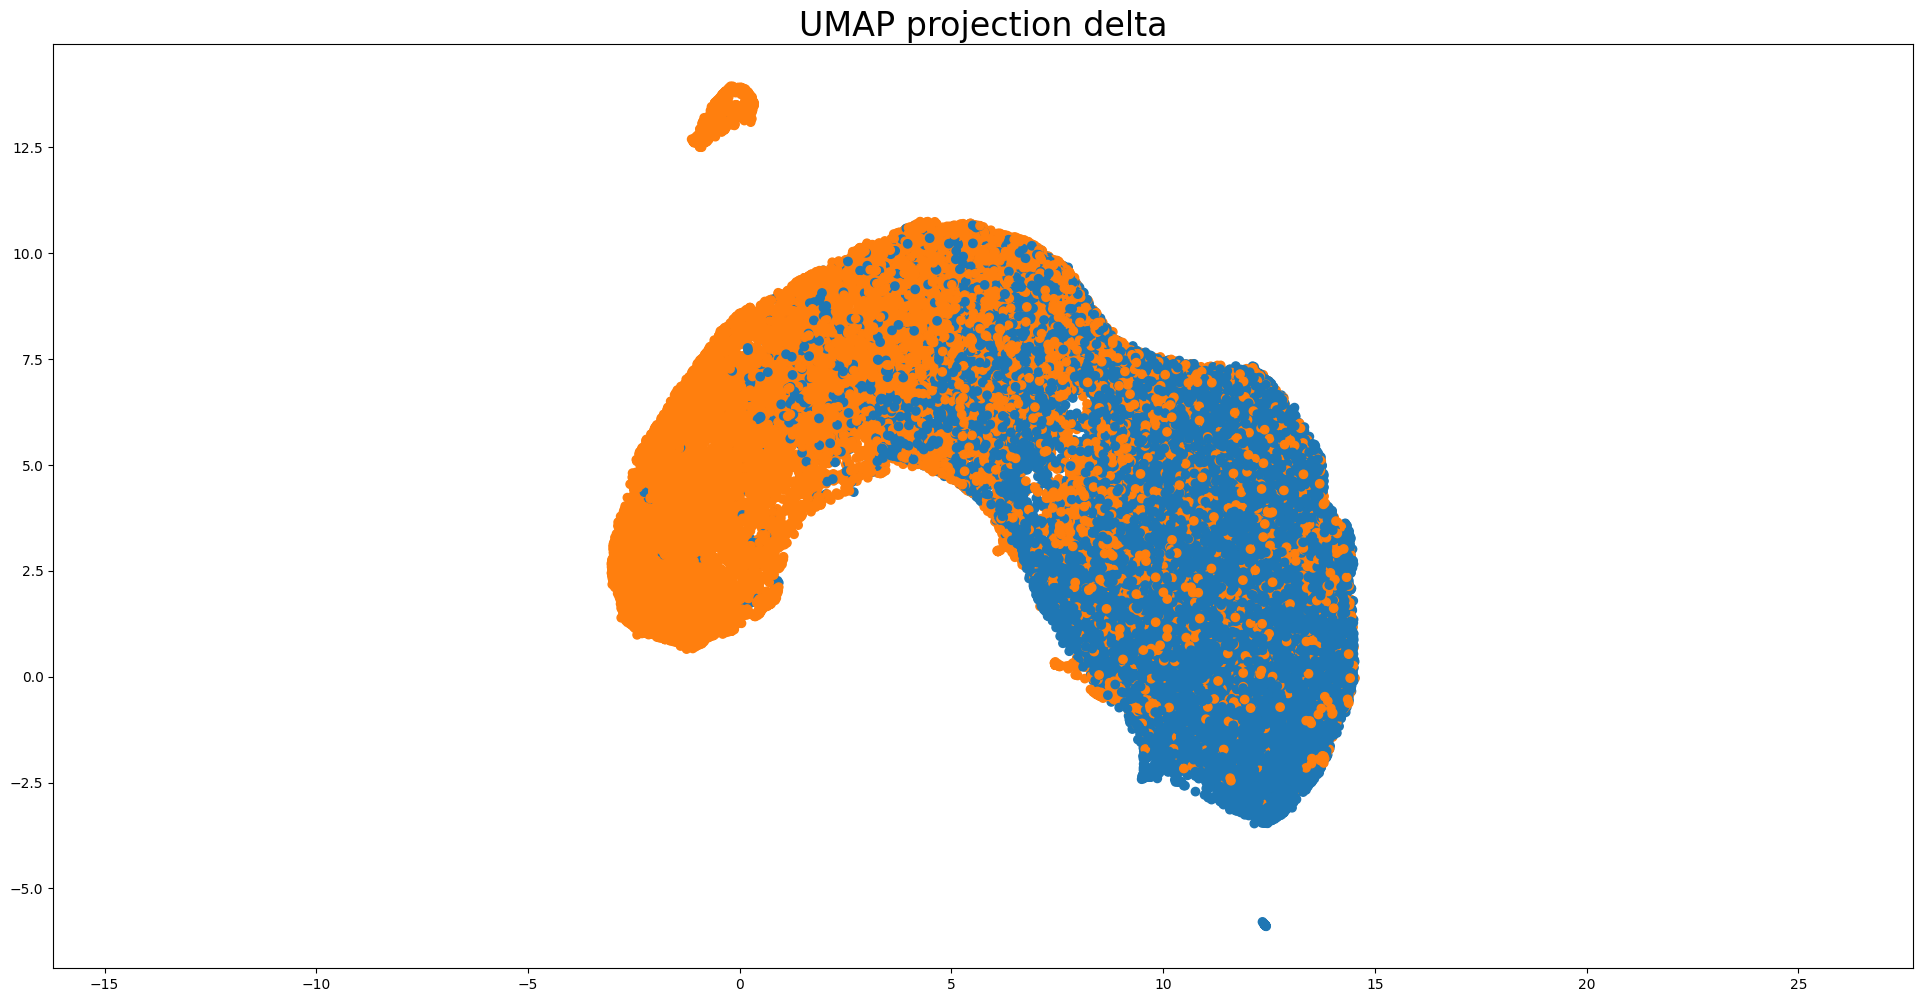

 17%|█▋        | 1/6 [00:08<00:44,  8.86s/it]

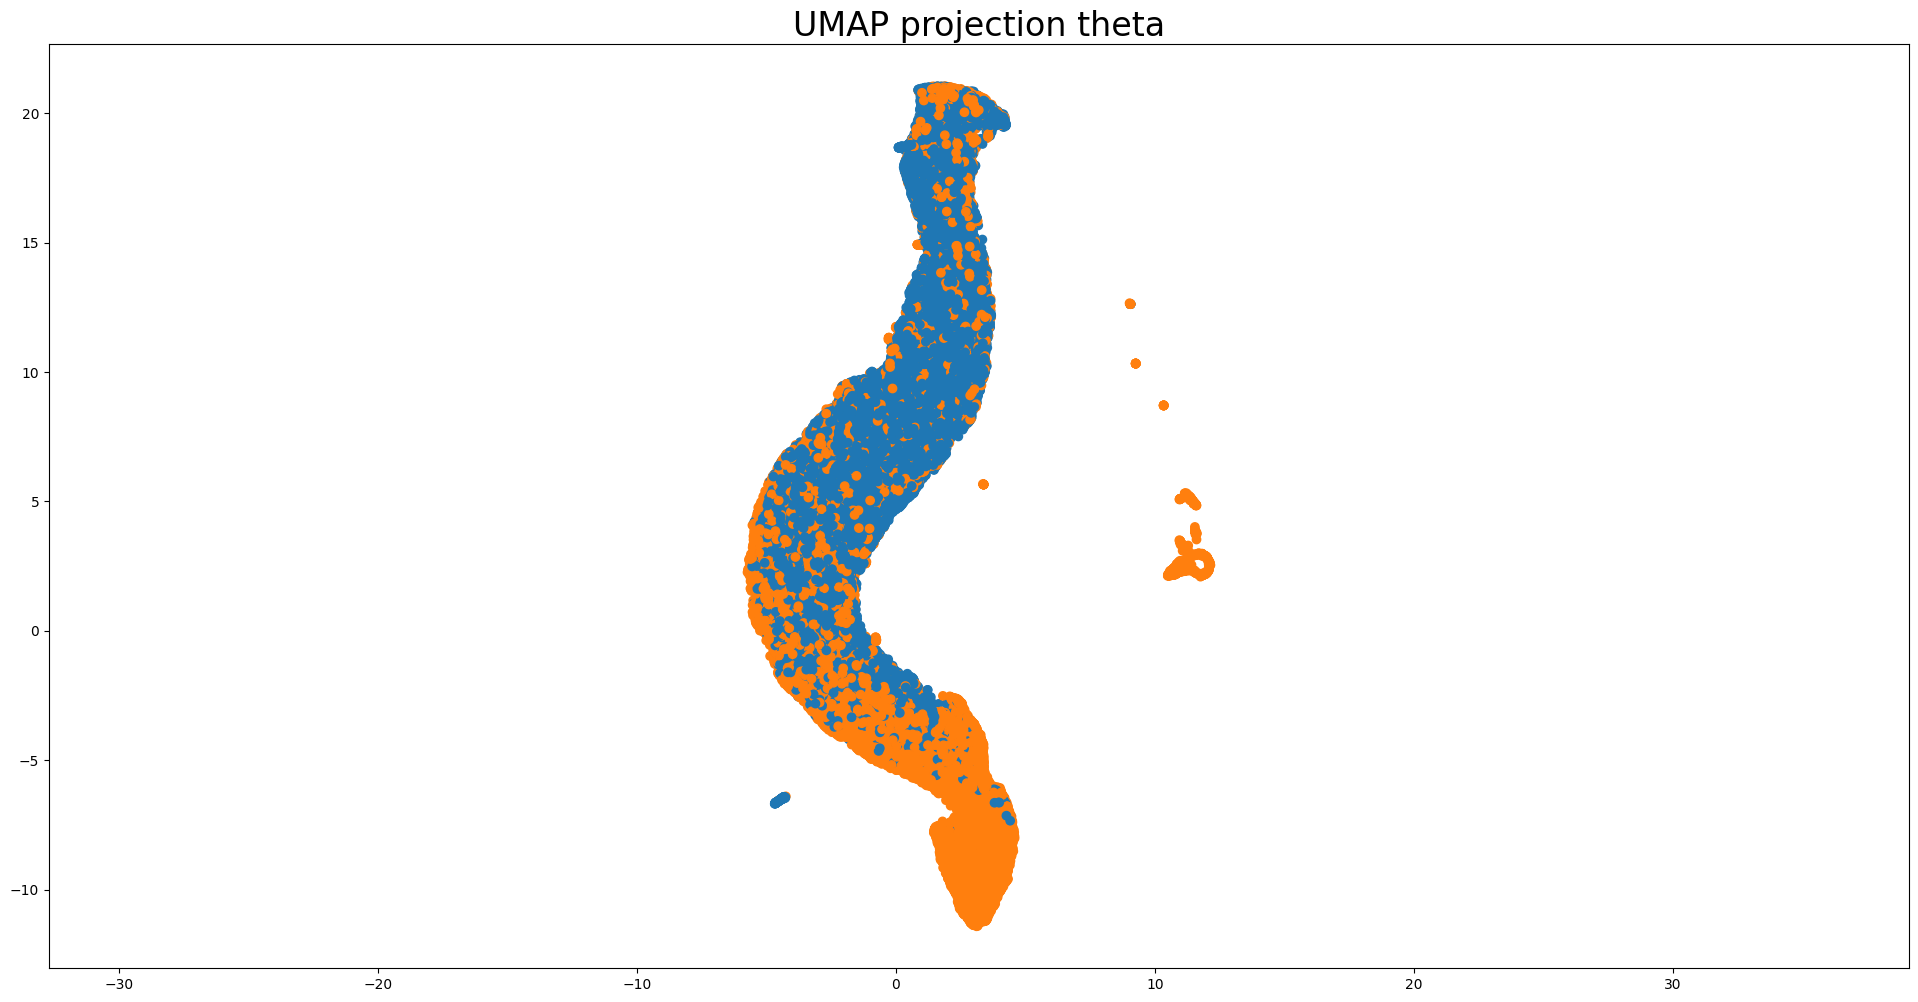

 33%|███▎      | 2/6 [00:17<00:36,  9.02s/it]

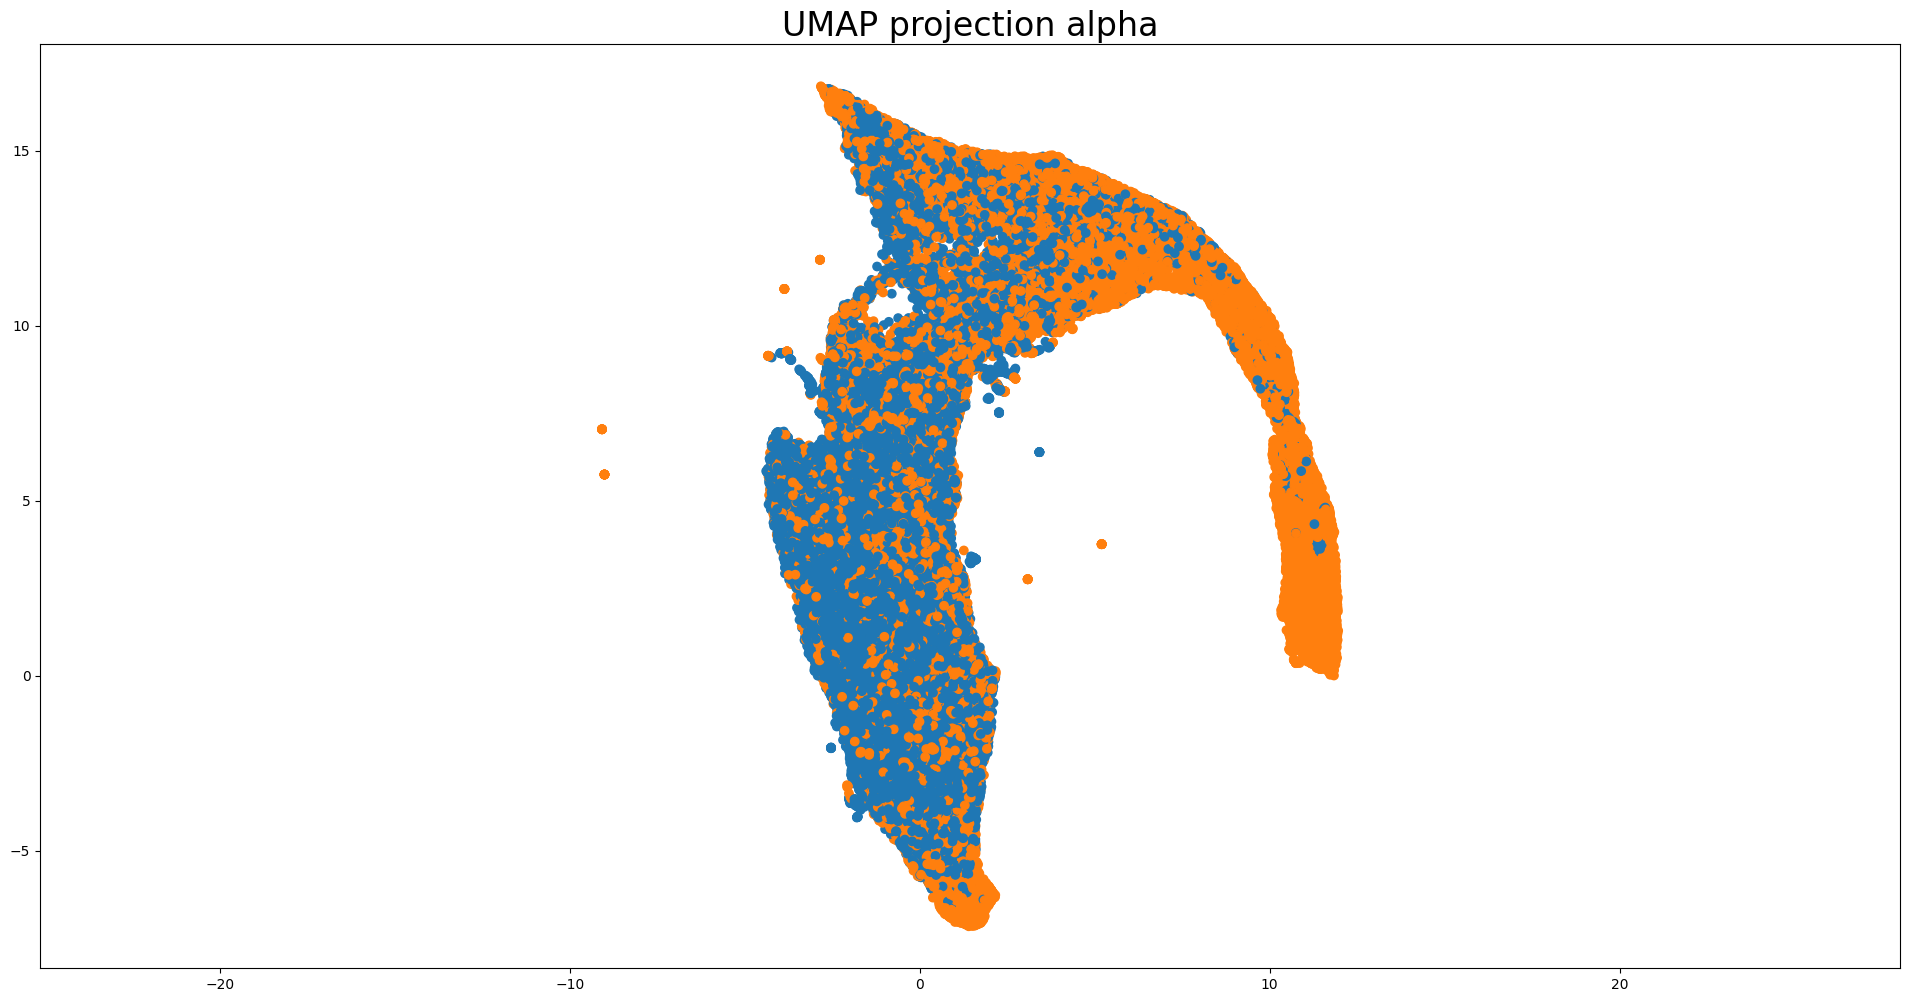

 50%|█████     | 3/6 [00:27<00:27,  9.06s/it]

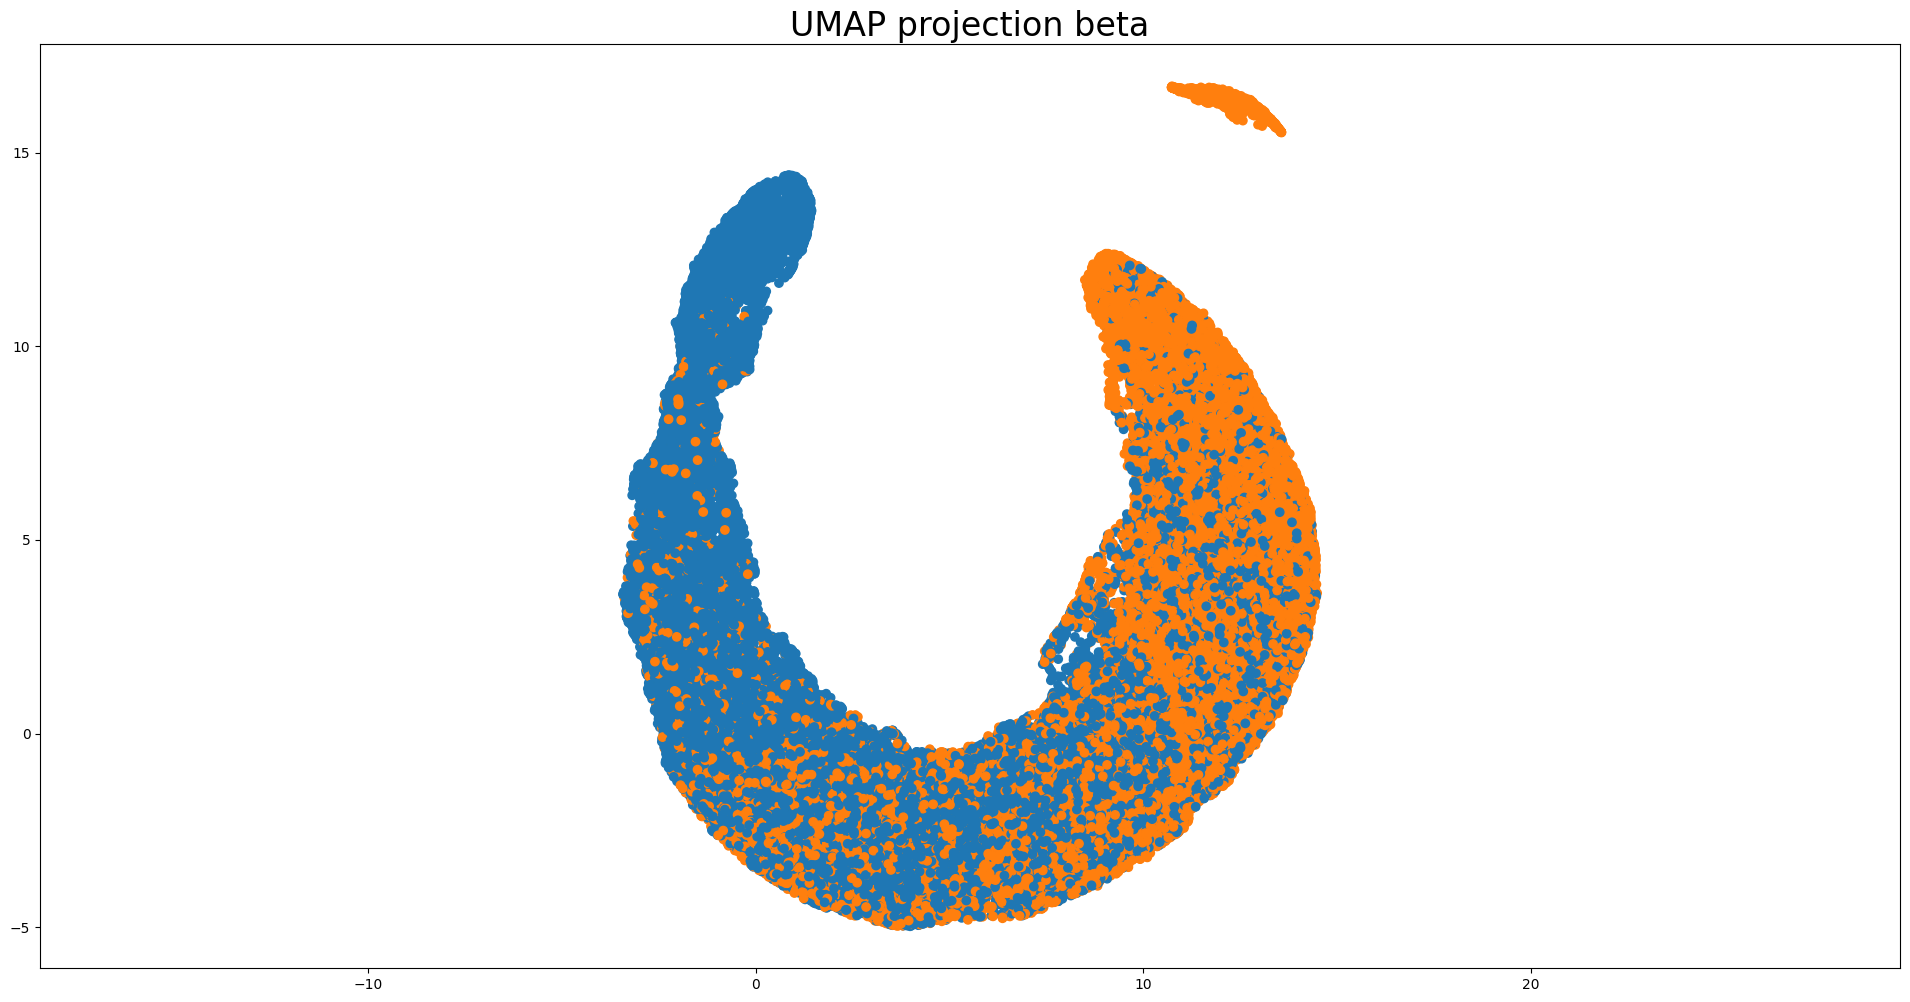

 67%|██████▋   | 4/6 [00:36<00:18,  9.00s/it]

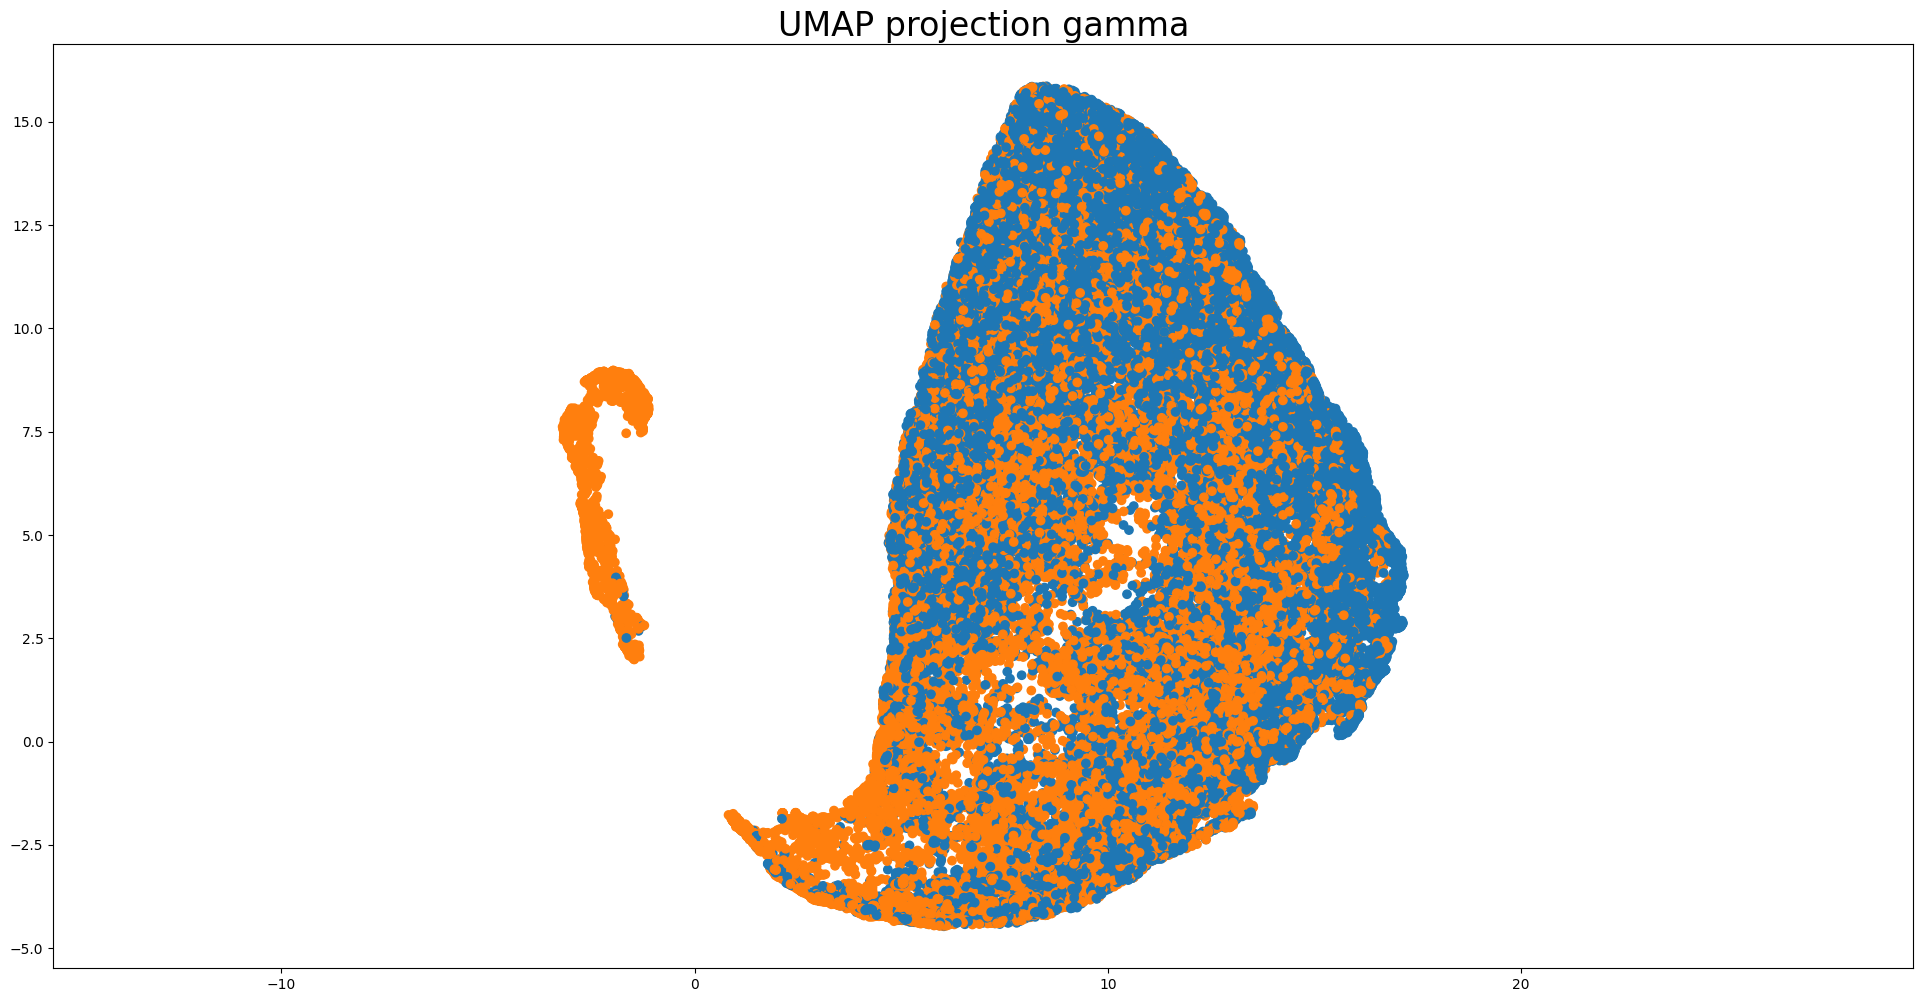

 83%|████████▎ | 5/6 [00:44<00:08,  8.99s/it]

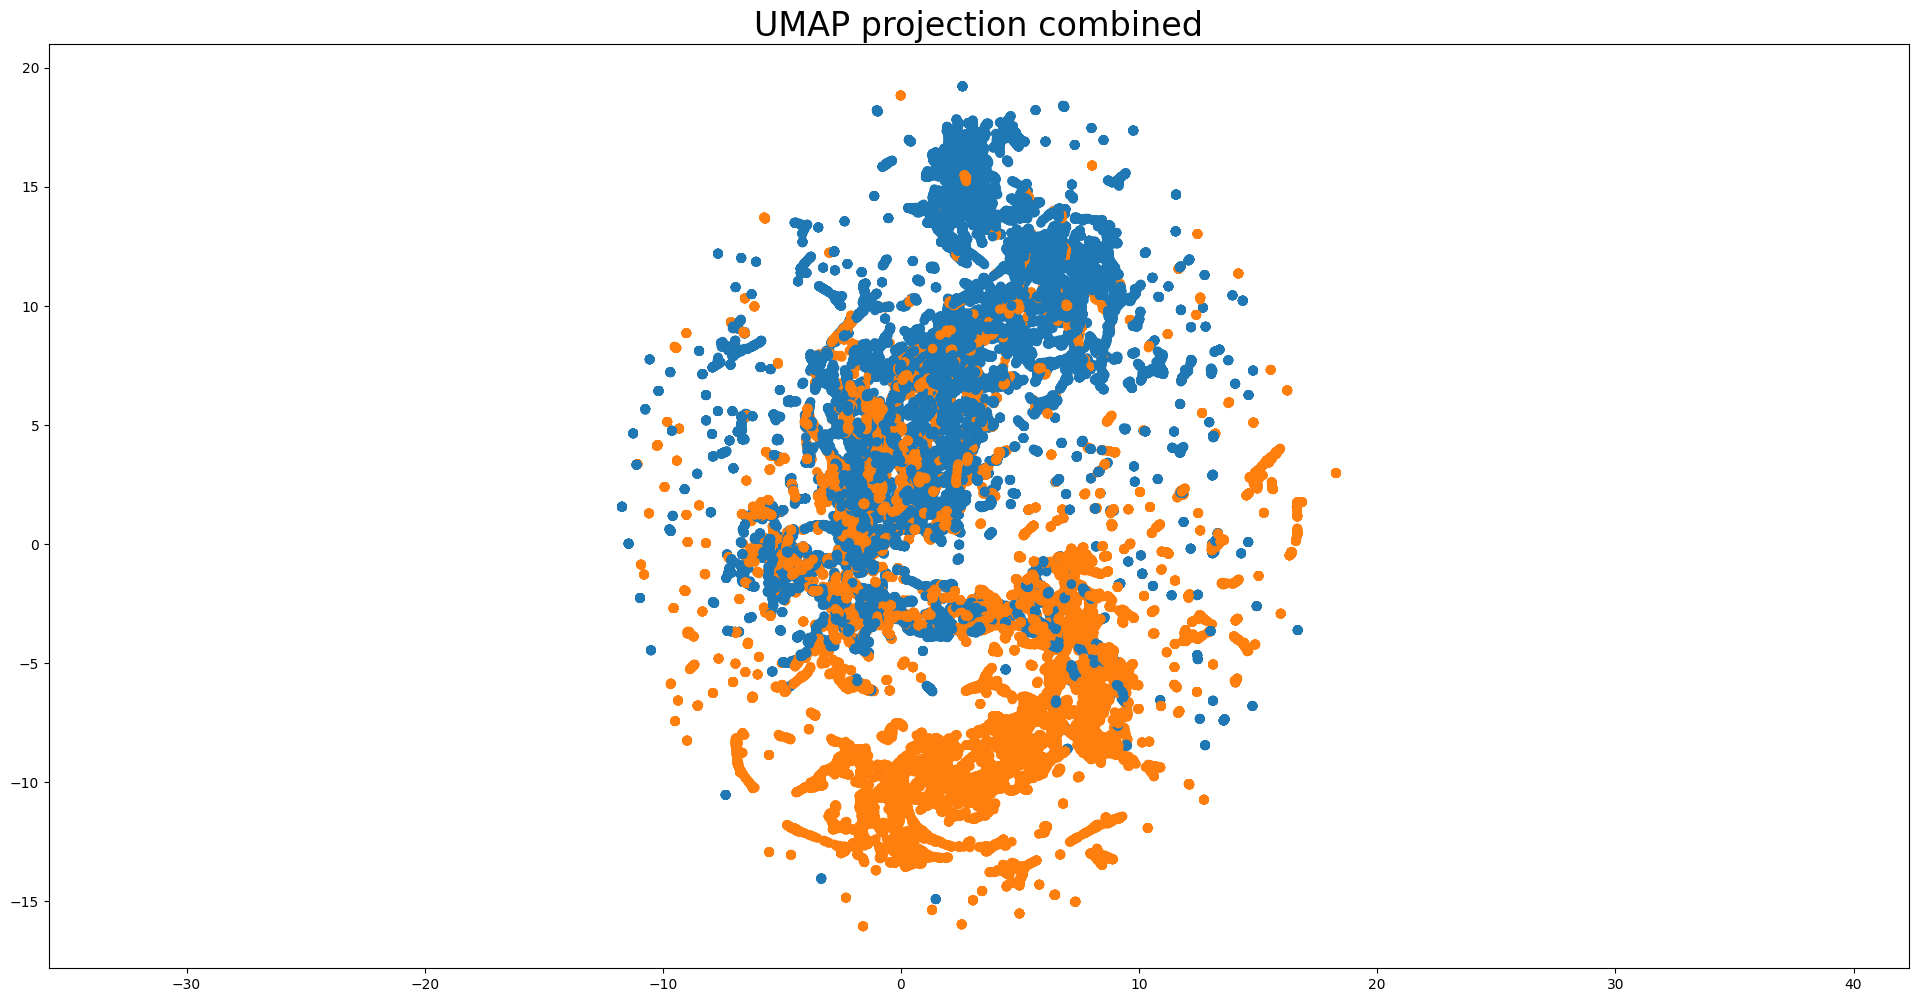

100%|██████████| 6/6 [00:56<00:00,  9.44s/it]


In [28]:
for band in tqdm.tqdm(['delta', 'theta', 'alpha', 'beta', 'gamma', 'combined']):
#for band in tqdm.tqdm(['combined']):
    if band == 'combined':
        embeddings = reducer2.fit_transform(combined_output_eval_all, job=-1)
    else:
        data = encoding_output_eval_all[band].reshape(encoding_output_eval_all[band].shape[0], -1)
        embeddings = reducer2.fit_transform(data, jobs=-1)
    fig = plt.figure(figsize=(24, 12))
    ax = fig.add_subplot()
    ax.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        c=[sns.color_palette()[x] for x in output_labels_eval_all])
    plt.gca().set_aspect('equal', 'datalim')
    plt.title(f'UMAP projection {band}', fontsize=24)
    plt.show()

In [25]:
print(final_embeddings_eval_all.shape)

(66737, 95)


In [31]:
embeddings = reducer2.fit_transform(final_embeddings_eval_all, job=-1)
fig = plt.figure(figsize=(24, 12))
ax = fig.add_subplot()
ax.scatter(
    embeddings[:, 0],
    embeddings[:, 1],
    c=[sns.color_palette()[x] for x in output_labels_eval_all])
plt.gca().set_aspect('equal', 'datalim')
plt.title(f'UMAP projection Final Embeddings', fontsize=24)
plt.show()

TypeError: UMAP._fit_embed_data() got multiple values for argument 'n_epochs'

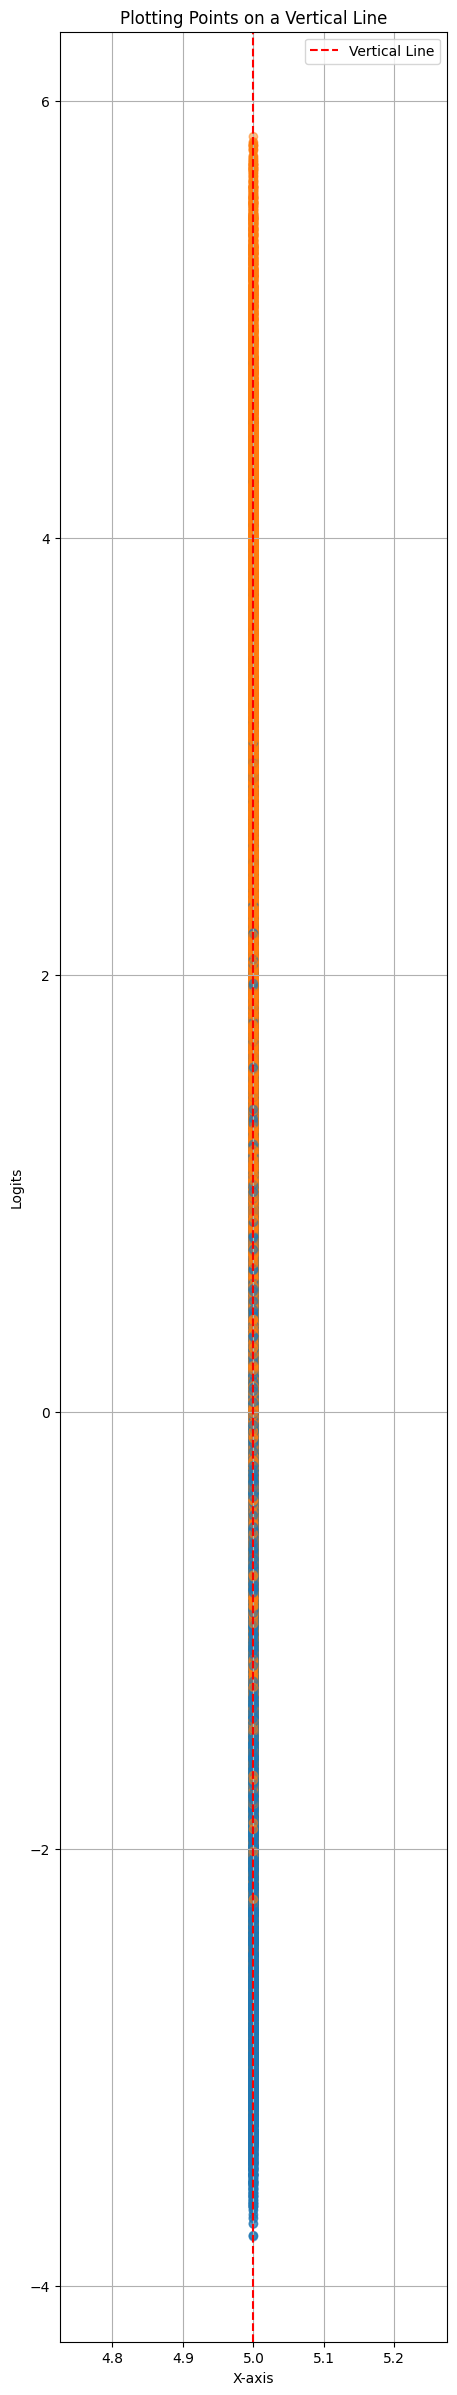

In [25]:
# Define the x-coordinate of the vertical line
x_value = 5

plt.figure(figsize=(5, 30))
# Plot the vertical line
plt.axvline(x=x_value, color='r', linestyle='--', label='Vertical Line')
plt.scatter(
    [x_value] * predictions.shape[0],
    predictions,
    c=[sns.color_palette()[x] for x in output_labels_eval_all],
    alpha=0.5)

# Customize the plot
plt.xlabel('X-axis')
plt.ylabel('Logits')
plt.title('Plotting Points on a Vertical Line')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

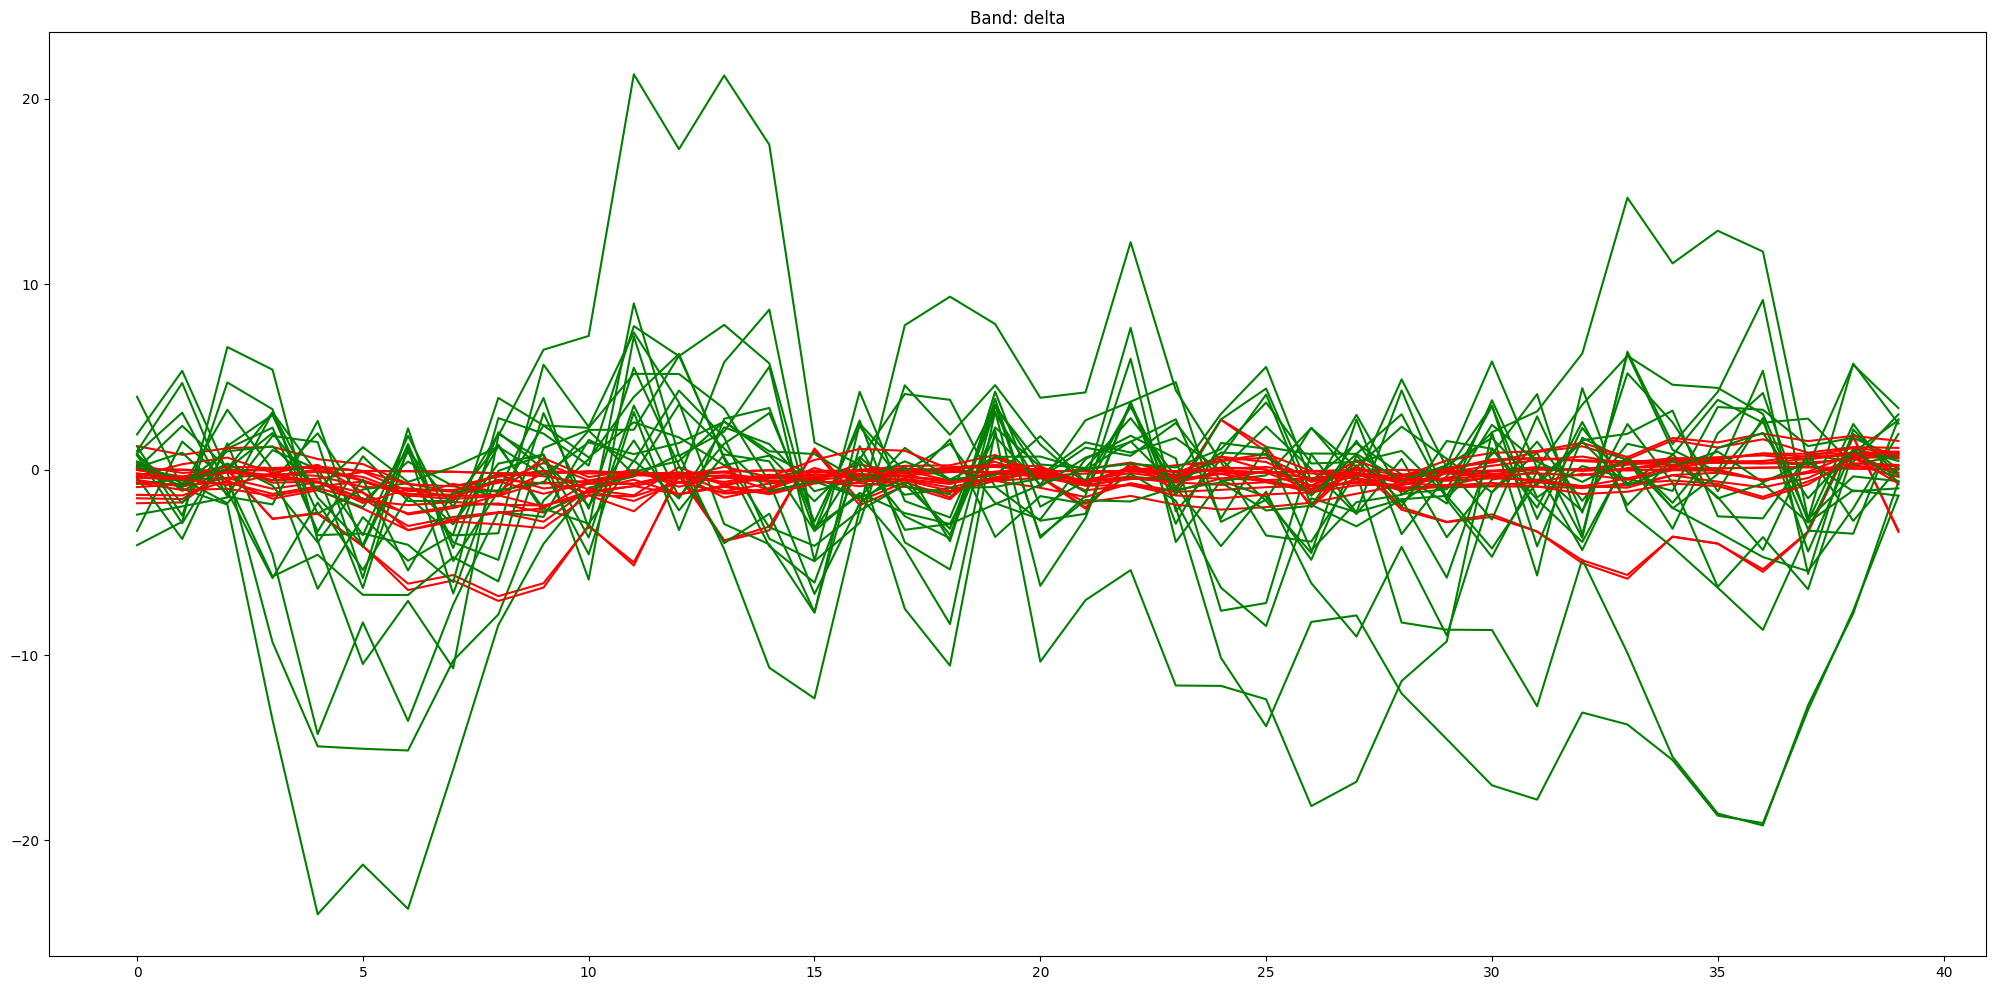

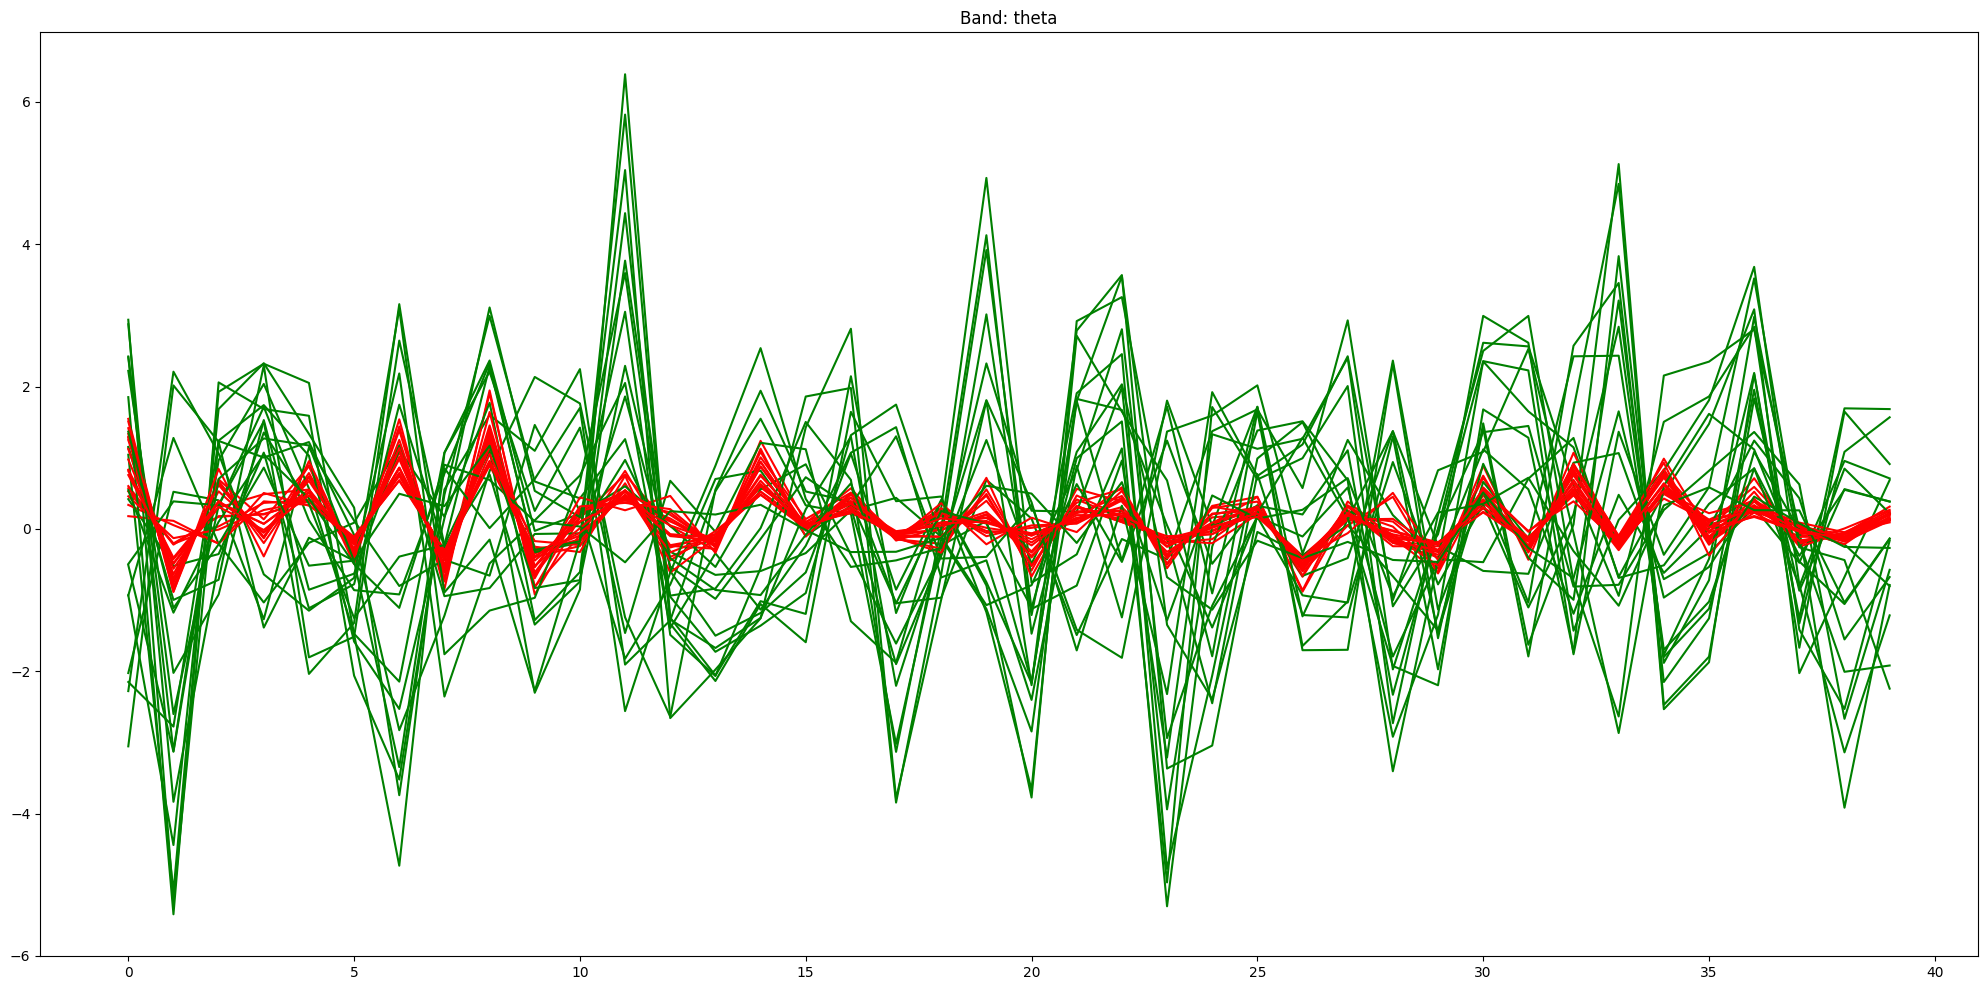

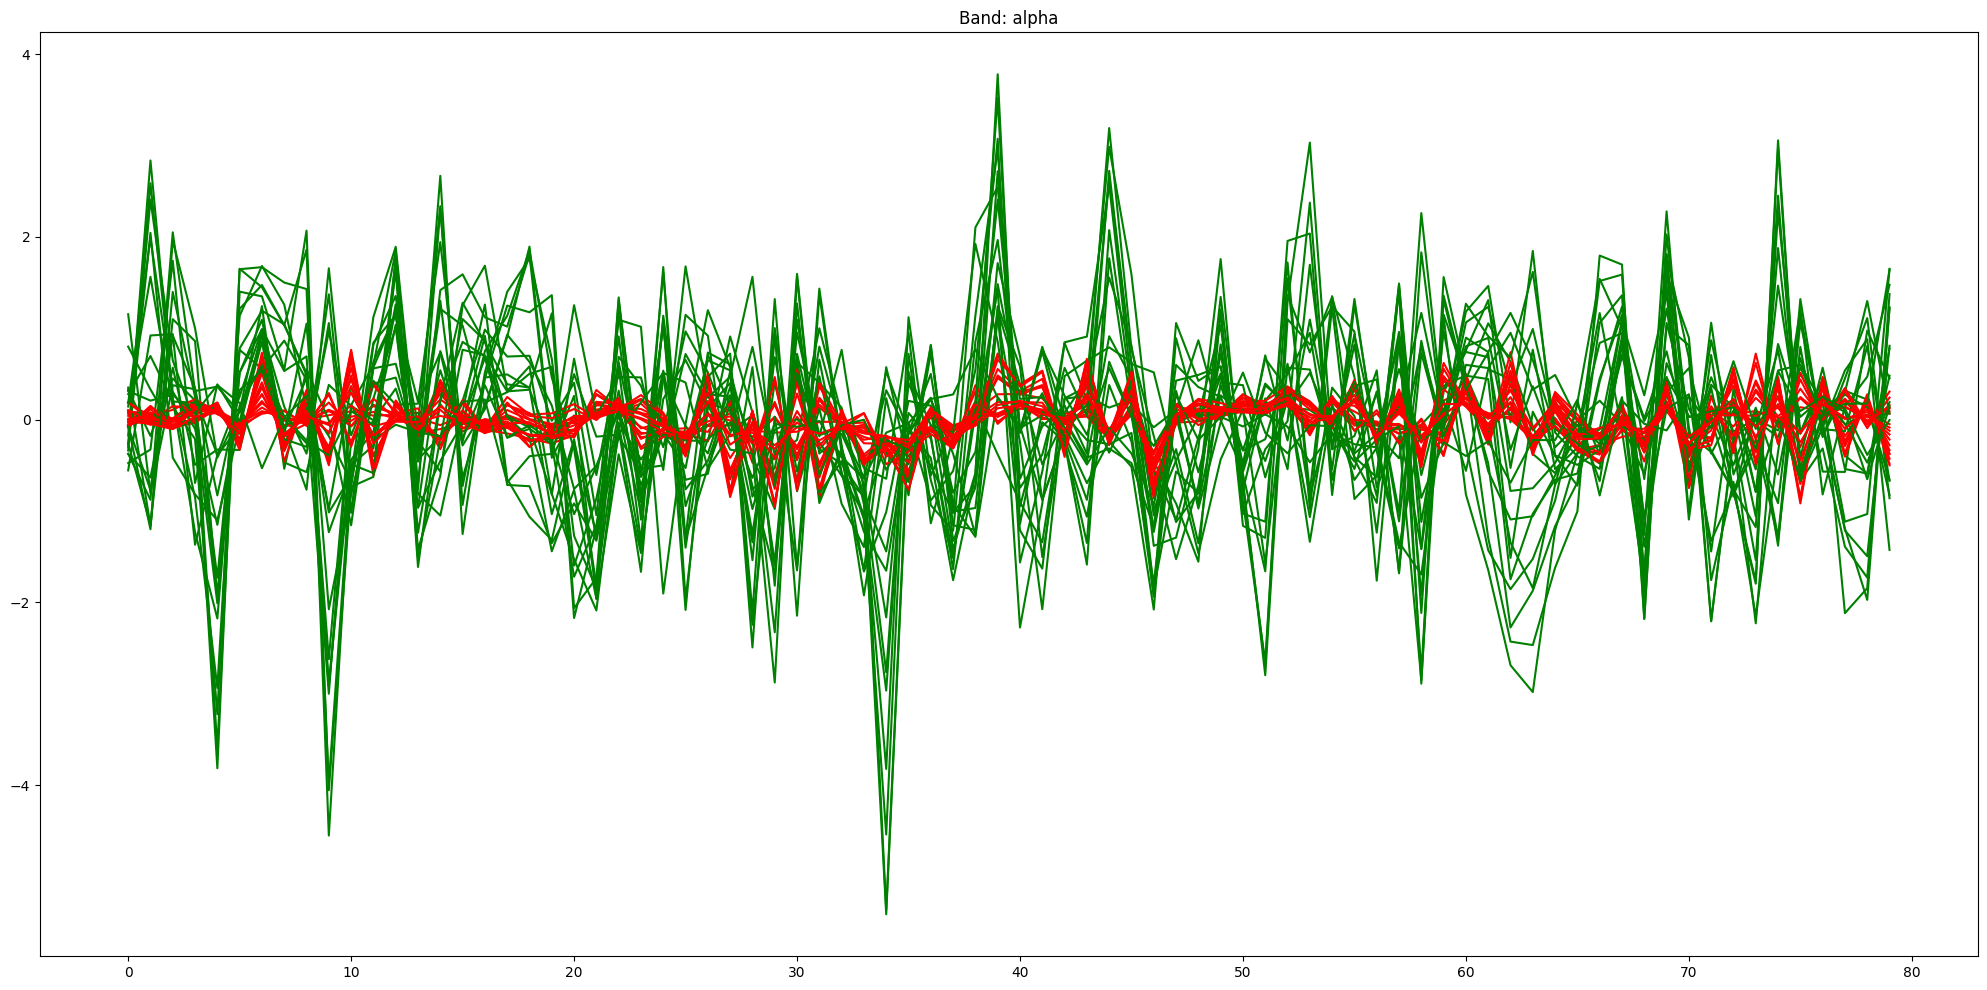

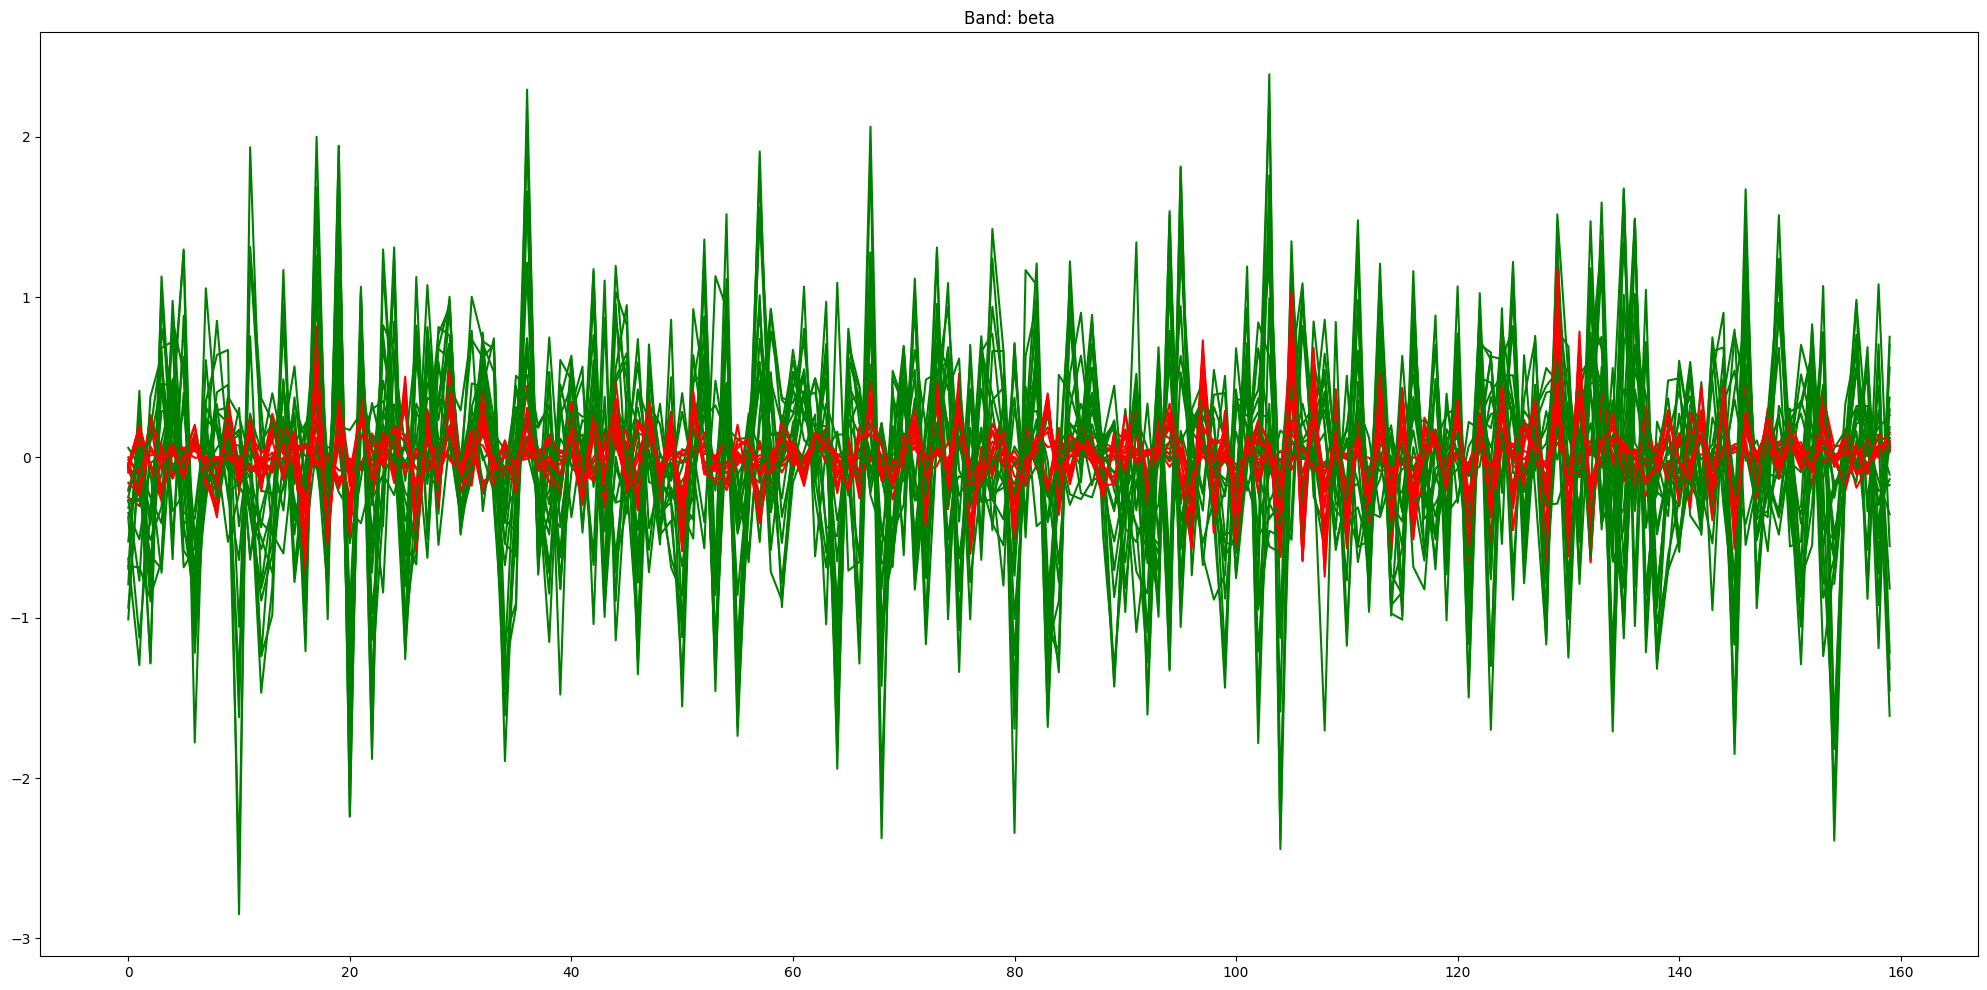

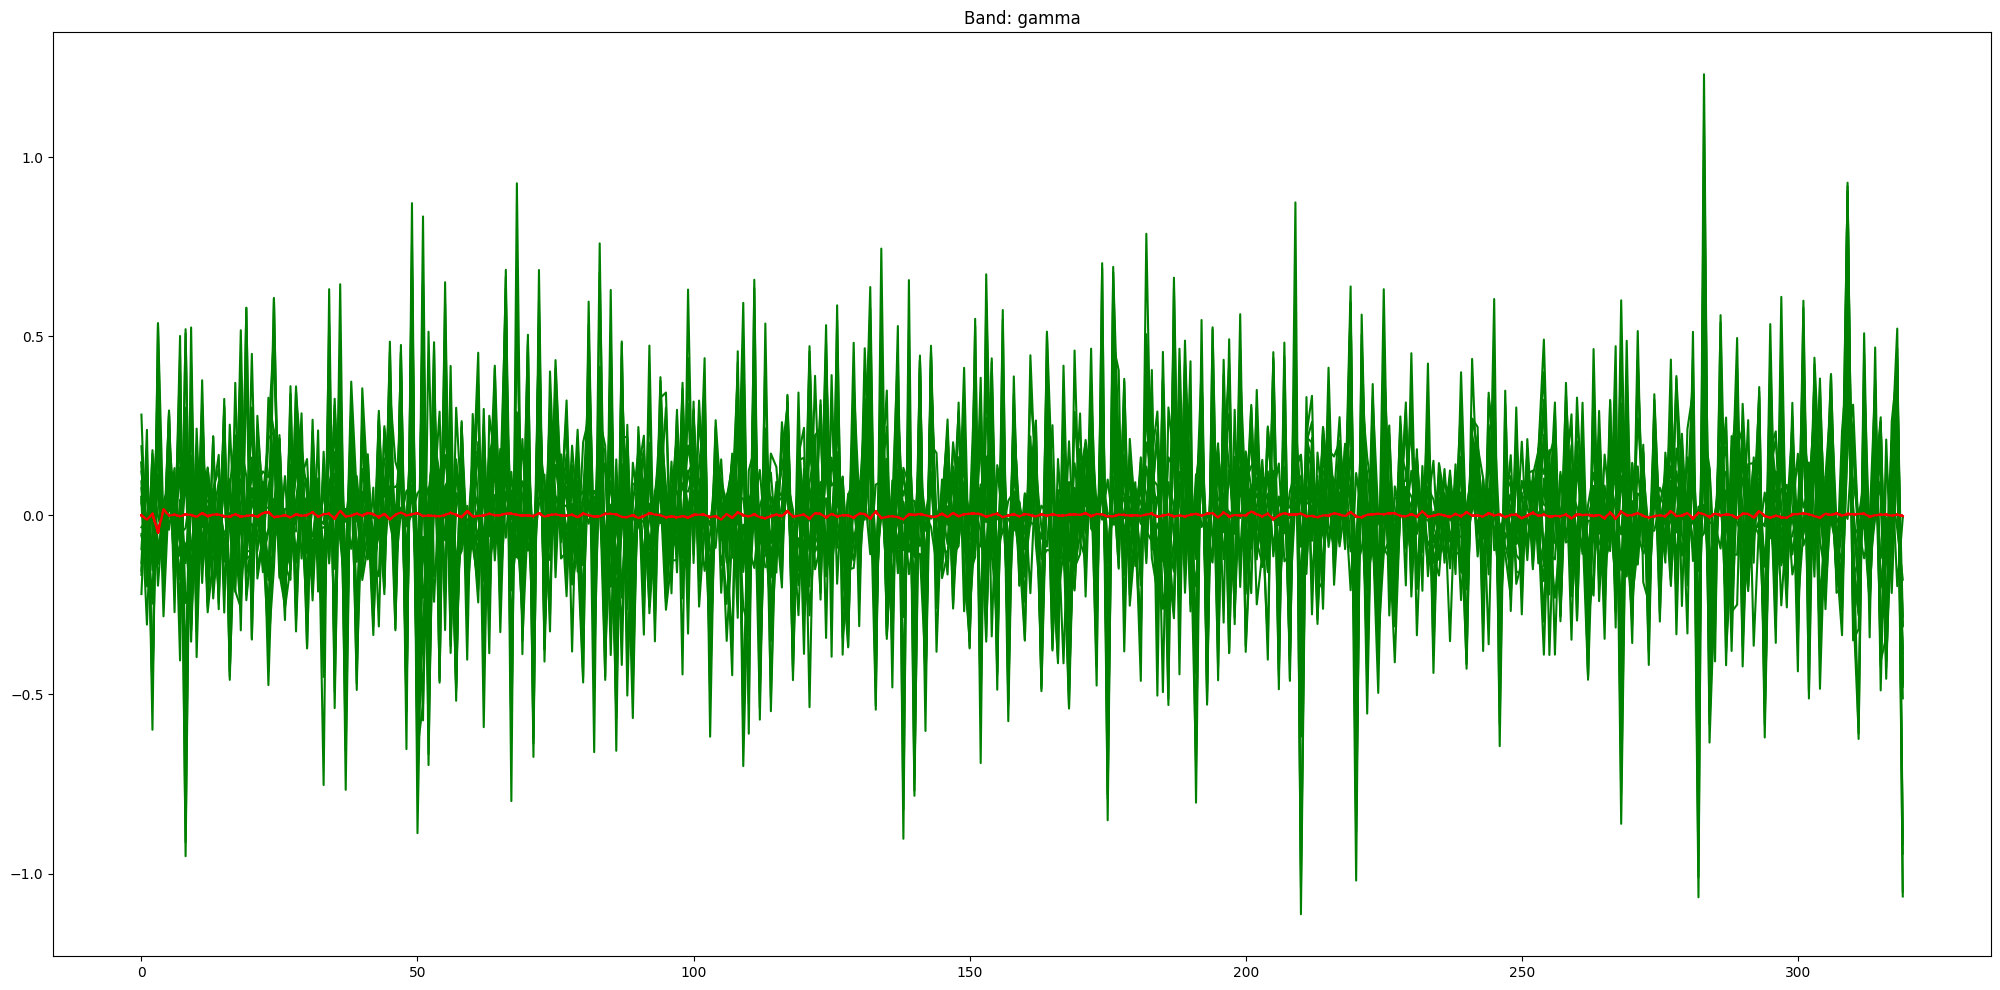

In [30]:
channel = 5
for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
    plt.figure(figsize=(25, 12))
    for channel in range(19):
        plt.plot(patchified_inputs[band][6, 3, channel, :].cpu().detach().numpy(), label=f"Input {band} Channel {channel}", c="g")
        decoding_plot = decodings[band].reshape(patchified_inputs[band].shape[0], patchified_inputs[band].shape[1], patchified_inputs[band].shape[2], patchified_inputs[band].shape[3])
        plt.plot(decoding_plot[6, 3, channel, :].cpu().detach().numpy(), label=f"Output {band} Channel {channel}", c="r")
    plt.title(f"Band: {band}")
    #plt.legend()
    plt.show()

In [12]:
from torch.utils.tensorboard import SummaryWriter

In [13]:
writer = SummaryWriter('tensorboard_runs/test4') # Create a folder for logs

In [14]:
# Assuming 'model' is your PyTorch model
for name, param in model.named_parameters():
    writer.add_histogram(name, param.data.cpu().numpy()) # Log after each epoch